<a href="https://colab.research.google.com/github/Adithyanbiju10/AI_ML_Internship/blob/main/classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path=kagglehub.dataset_download("jp797498e/twitter-entity-sentiment-analysis")
print("Path to dataset files:",path)

Using Colab cache for faster access to the 'twitter-entity-sentiment-analysis' dataset.
Path to dataset files: /kaggle/input/twitter-entity-sentiment-analysis


In [2]:
import os

# List the contents of the directory
file_list=os.listdir(path)
print("Files in the dataset directory:", file_list)

Files in the dataset directory: ['twitter_validation.csv', 'twitter_training.csv']


In [3]:
import pandas as pd
import os

# Define column names based on common sentiment analysis dataset structures
column_names = ['Tweet_ID', 'Entity', 'Sentiment', 'Tweet']

# Load twitter_training.csv with no header and assign column names
train_df = pd.read_csv(os.path.join(path, 'twitter_training.csv'), header=None, names=column_names)
print('--- Training Data (twitter_training.csv) with fixed headers ---')
display(train_df.head())

--- Training Data (twitter_training.csv) with fixed headers ---


,Tweet_ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [4]:
import pandas as pd
import os

# Define column names based on common sentiment analysis dataset structures
column_names = ['Tweet_ID', 'Entity', 'Sentiment', 'Tweet']

# Load twitter_validation.csv with no header and assign column names
valid_df = pd.read_csv(os.path.join(path, 'twitter_validation.csv'), header=None, names=column_names)
print('\n--- Validation Data (twitter_validation.csv) with fixed headers ---')
display(valid_df.head())


--- Validation Data (twitter_validation.csv) with fixed headers ---


,Tweet_ID,Entity,Sentiment,Tweet
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


In [5]:
train_df.to_csv('twitter_training.csv', index=False)
valid_df.to_csv('twitter_validation.csv', index=False)


Generating Sentiment Distribution Chart...


/tmp/ipykernel_1296/1600430375.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


Text(0, 0.5, 'Number of Tweets')

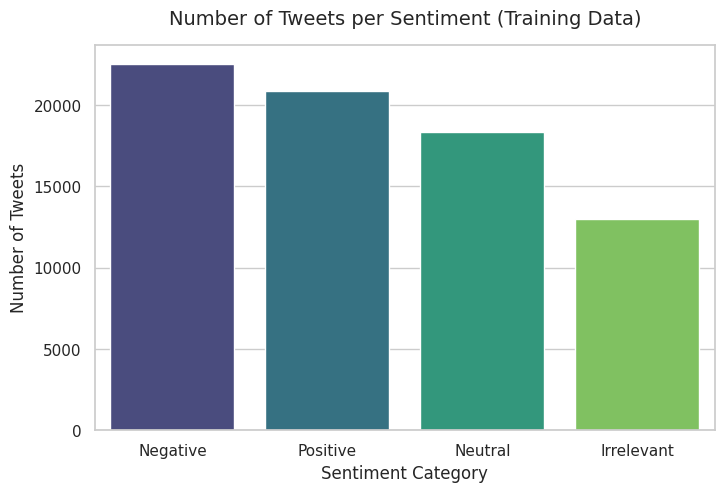

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Make the charts look modern and clean
sns.set_theme(style="whitegrid")

# ==========================================
# VISUALIZATION 1: Class Distribution
# ==========================================
print("\nGenerating Sentiment Distribution Chart...")

# Create a chart layout
fig, ax = plt.subplots(figsize=(8, 5))

# Plot the count of each sentiment in the training data, sorted from highest to lowest
sns.countplot(
    data=train_df,
    x='Sentiment',
    order=train_df['Sentiment'].value_counts().index,
    palette='viridis',
    ax=ax
)

# Add titles and labels
ax.set_title('Number of Tweets per Sentiment (Training Data)', fontsize=14, pad=15)
ax.set_xlabel('Sentiment Category', fontsize=12)
ax.set_ylabel('Number of Tweets', fontsize=12)


Generating Entity Sentiment Stacked Bar Chart...


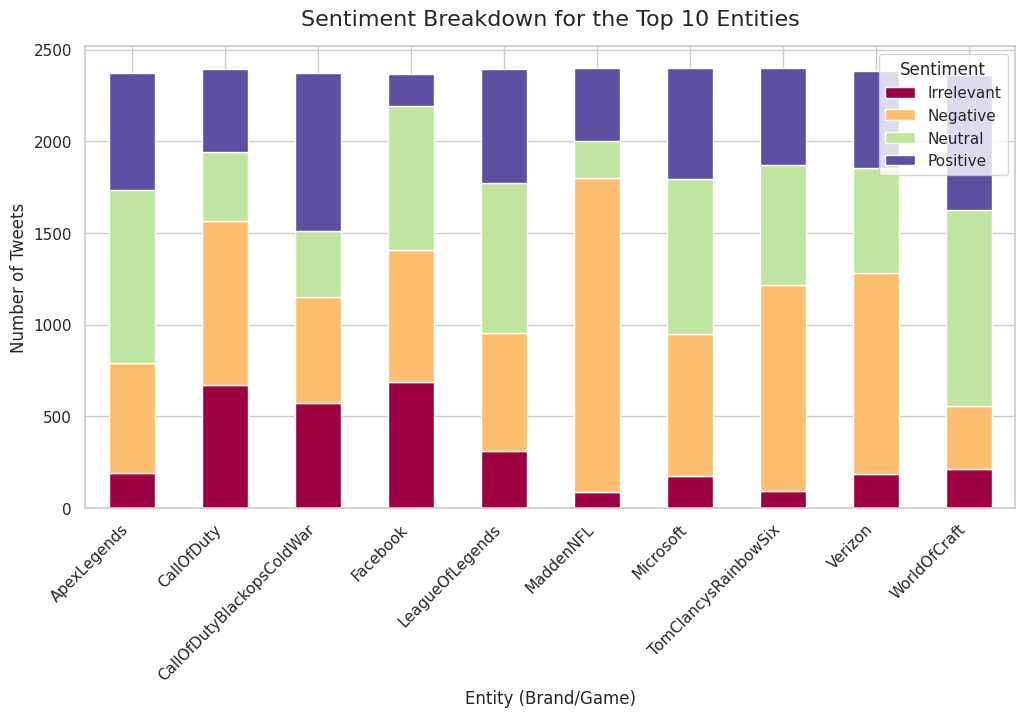

In [7]:
print("\nGenerating Entity Sentiment Stacked Bar Chart...")

# Find the top 10 most talked about entities in the dataset
top_10_entities = train_df['Entity'].value_counts().nlargest(10).index

# Filter the dataset to only include those top 10 entities
top_entities_df = train_df[train_df['Entity'].isin(top_10_entities)]

# Group the data by Entity and Sentiment to get the counts
entity_sentiment_counts = top_entities_df.groupby(['Entity', 'Sentiment']).size().unstack(fill_value=0)

# Create a stacked bar chart
fig3, ax3 = plt.subplots(figsize=(12,6))
entity_sentiment_counts.plot(kind='bar', stacked=True, ax=ax3, colormap='Spectral')

ax3.set_title('Sentiment Breakdown for the Top 10 Entities', fontsize=16, pad=15)
ax3.set_xlabel('Entity (Brand/Game)', fontsize=12)
ax3.set_ylabel('Number of Tweets', fontsize=12)
plt.xticks(rotation=45, ha='right') # Tilt the labels so they are easy to read
plt.legend(title='Sentiment')

plt.show()

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score

# --- STEP 1: CLEAN THE DATA ---
# Kaggle's documentation tells us these are the correct column names
column_names = ['Tweet_ID', 'Entity', 'Sentiment', 'Tweet']
train_df.columns = column_names
valid_df.columns = column_names

# Drop any rows where the actual tweet text is missing
train_df = train_df.dropna(subset=['Tweet'])
valid_df = valid_df.dropna(subset=['Tweet'])

# Separate our inputs (the tweets) from our targets (the sentiment labels)
X_train = train_df['Tweet']
y_train = train_df['Sentiment']

X_valid = valid_df['Tweet']
y_valid = valid_df['Sentiment']

# --- STEP 2 & 3: BUILD AND TRAIN THE MODEL ---
print("Training the classification model... (this takes a few seconds)")

# A pipeline automatically handles turning text to numbers, then training the model
model = make_pipeline(
    TfidfVectorizer(max_features=10000), # Keeps the top 10,000 most important words
    MultinomialNB()                      # A classic text classification algorithm
)

# Teach the model using the training data
model.fit(X_train, y_train)
print("Model training complete!\n")

# --- STEP 4: TEST THE MODEL ---
# Ask the model to predict the sentiments of the validation data
predictions = model.predict(X_valid)

# Show the results!
print("--- Final Evaluation ---")
print(f"Accuracy: {accuracy_score(y_valid, predictions) * 100:.2f}%\n")
print(classification_report(y_valid, predictions))

Training the classification model... (this takes a few seconds)
Model training complete!

--- Final Evaluation ---
Accuracy: 73.80%

              precision    recall  f1-score   support

  Irrelevant       0.89      0.55      0.68       172
    Negative       0.66      0.86      0.75       266
     Neutral       0.83      0.61      0.71       285
    Positive       0.71      0.86      0.78       277

    accuracy                           0.74      1000
   macro avg       0.77      0.72      0.73      1000
weighted avg       0.76      0.74      0.73      1000



Generating Confusion Matrix Heatmap...


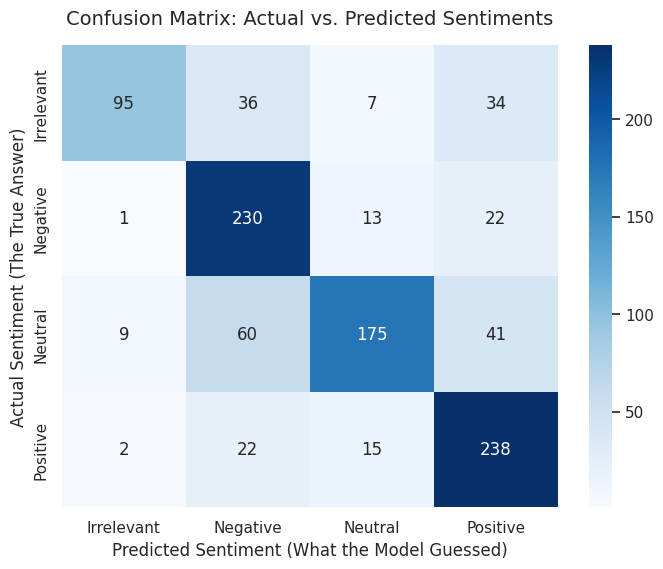

In [9]:
print("Generating Confusion Matrix Heatmap...")

# Calculate the raw numbers of correct vs. incorrect guesses
cm = confusion_matrix(y_valid, predictions, labels=model.classes_)

# Create a new chart layout
fig2, ax2 = plt.subplots(figsize=(8, 6))

# Use Seaborn to turn the numbers into a color-coded heatmap
sns.heatmap(
    cm,
    annot=True,     # Show the actual numbers inside the boxes
    fmt='d',        # Format the numbers as standard integers
    cmap='Blues',   # Use a blue color scale
    xticklabels=model.classes_,
    yticklabels=model.classes_,
    ax=ax2
)

# Add titles and labels
ax2.set_title('Confusion Matrix: Actual vs. Predicted Sentiments', fontsize=14, pad=15)
ax2.set_xlabel('Predicted Sentiment (What the Model Guessed)', fontsize=12)
ax2.set_ylabel('Actual Sentiment (The True Answer)', fontsize=12)

plt.show()

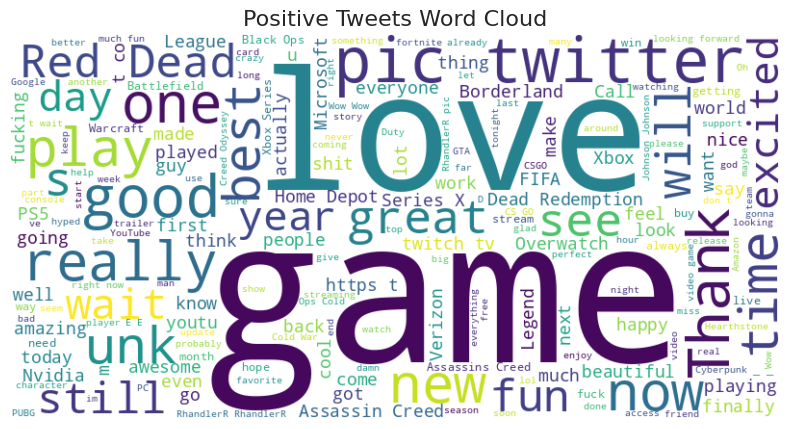

In [10]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 1. Grab all the text for the Positive tweets
positive_text = " ".join(train_df[train_df['Sentiment'] == 'Positive']['Tweet'].astype(str))

# 2. Generate the word cloud
simple_cloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

# 3. Display it directly on the screen!
plt.figure(figsize=(10, 5)) # Sets the window size
plt.imshow(simple_cloud, interpolation='bilinear')
plt.axis("off") # Hides the graph numbers and gridlines
plt.title("Positive Tweets Word Cloud", fontsize=16)
plt.show()      # This is the magic command that pops it up on your screen